<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%964_%D0%9F%D0%BE%D1%81%D1%82%D1%80%D0%BE%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B9_%D1%81%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D0%BE%D0%B9_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B9_%D1%81%D0%B5%D1%82%D0%B8_%D0%B4%D0%BB%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D1%81_%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%D0%BC_BatchNormalization_%D0%B8_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [1]:
# 1.1 Загрузка исходного датасета CIFAR-100 и разбиение на train/test
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, models, callbacks

SEED = 42
BATCH_SIZE = 128
EPOCHS = 20

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Используем sparse-метки: y имеют форму (N, 1) и содержат целочисленные классы 0..99
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode="fine")
y_train = y_train.squeeze()
y_test = y_test.squeeze()

num_classes = 100
input_shape = x_train.shape[1:]

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")
print(f"input_shape: {input_shape}, num_classes: {num_classes}")


def make_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1,
        ),
    ]


def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
x_train: (50000, 32, 32, 3), y_train: (50000,)
x_test:  (10000, 32, 32, 3), y_test:  (10000,)
input_shape: (32, 32, 3), num_classes: 100


### **1.2. Визуализируйте несколько изображений из датасета:**


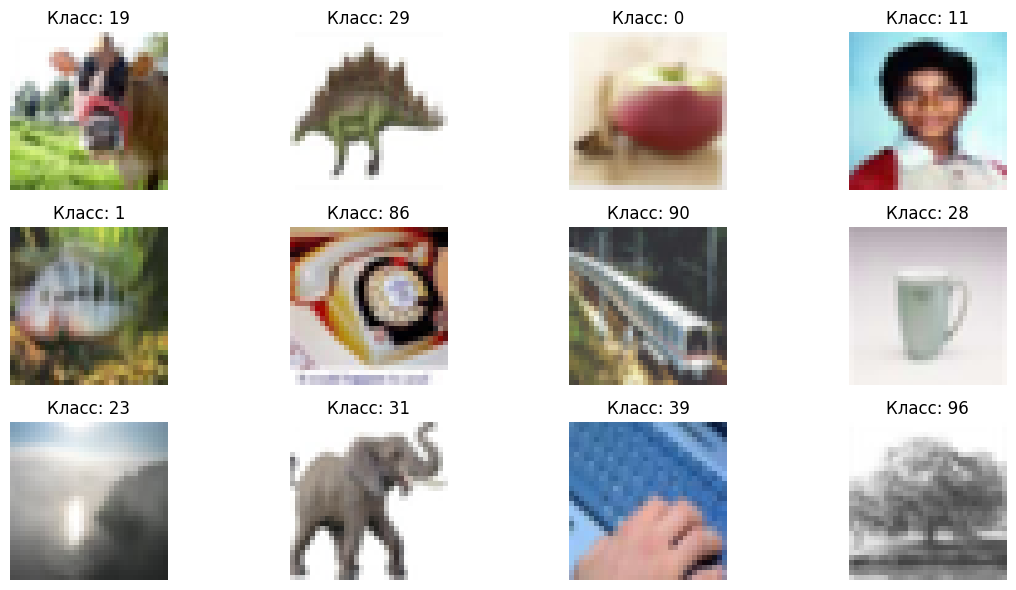

In [2]:
# 1.2 Визуализация нескольких изображений из датасета
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(f"Класс: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [3]:
# 1.3 Нормализация данных в диапазон [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Диапазон train:", x_train_norm.min(), x_train_norm.max())
print("Диапазон test:", x_test_norm.min(), x_test_norm.max())

Диапазон train: 0.0 1.0
Диапазон test: 0.0 1.0


### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [4]:
# 1.4 Модель без BatchNormalization и Dropout (model_1)
model_1 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_1_base",
)

model_1 = compile_model(model_1)
model_1.summary()

Model: "model_1_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,356 (8.45 MB)

 Trainable params: 2,216,356 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [5]:
# Обучение model_1
history_1 = model_1.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_1, test_acc_1 = model_1.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_1 test accuracy: {test_acc_1:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.1277 - loss: 3.7887 - val_accuracy: 0.2055 - val_loss: 3.3099 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2675 - loss: 3.0006 - val_accuracy: 0.2863 - val_loss: 2.8967 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3480 - loss: 2.5953 - val_accuracy: 0.3238 - val_loss: 2.7228 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4067 - loss: 2.3117 - val_accuracy: 0.3388 - val_loss: 2.7166 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4659 - loss: 2.0510 - val_accuracy: 0.3401 - val_loss: 2.7977 - learning_rate: 0.0010
Epoch 6/20
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5098 - loss: 1.8497
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5249 - loss: 1.7956 

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [6]:
# 1.5 Модель с BatchNormalization (model_2)
model_2 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_2_batchnorm",
)

model_2 = compile_model(model_2)
model_2.summary()

Model: "model_2_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,217,252 (8.46 MB)

 Trainable params: 2,216,804 (8.46 MB)

 Non-trainable params: 448 (1.75 KB)

Обучите созданную модель

In [7]:
# Обучение model_2
history_2 = model_2.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_2, test_acc_2 = model_2.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_2 test accuracy: {test_acc_2:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.1468 - loss: 3.7110 - val_accuracy: 0.0450 - val_loss: 5.2395 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3068 - loss: 2.7455 - val_accuracy: 0.2682 - val_loss: 2.9195 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3983 - loss: 2.3175 - val_accuracy: 0.3160 - val_loss: 2.7102 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4582 - loss: 2.0407 - val_accuracy: 0.3352 - val_loss: 2.6547 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5142 - loss: 1.8085 - val_accuracy: 0.3284 - val_loss: 2.7527 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5461 - loss: 1.6726
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5623 - loss: 1.6073 

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [8]:
# 1.6 Модель с Dropout (model_3)
model_3 = models.Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_3_dropout",
)

model_3 = compile_model(model_3)
model_3.summary()

Model: "model_3_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,356 (8.45 MB)

 Trainable params: 2,216,356 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [9]:
# Обучение model_3
history_3 = model_3.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_3, test_acc_3 = model_3.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_3 test accuracy: {test_acc_3:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.0461 - loss: 4.2868 - val_accuracy: 0.1108 - val_loss: 3.8815 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1184 - loss: 3.7829 - val_accuracy: 0.1806 - val_loss: 3.4323 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1714 - loss: 3.4747 - val_accuracy: 0.2352 - val_loss: 3.1386 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2073 - loss: 3.2724 - val_accuracy: 0.2604 - val_loss: 3.0103 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2325 - loss: 3.1251 - val_accuracy: 0.2853 - val_loss: 2.9039 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2560 - loss: 3.0000 - val_accuracy: 0.2966 - val_loss: 2.8462 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2744 - loss: 2.9054 

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [10]:
# 1.7 Модель с BatchNormalization + Dropout (model_4)
# Рекомендуемый порядок: Conv -> BatchNorm -> ReLU -> Pooling -> Dropout
model_4 = models.Sequential(
    [
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="model_4_bn_dropout",
)

model_4 = compile_model(model_4)
model_4.summary()

Model: "model_4_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,217,252 (8.46 MB)

 Trainable params: 2,216,804 (8.46 MB)

 Non-trainable params: 448 (1.75 KB)

Обучите созданную модель

In [11]:
# Обучение model_4
history_4 = model_4.fit(
    x_train_norm,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    verbose=1,
)

test_loss_4, test_acc_4 = model_4.evaluate(x_test_norm, y_test, verbose=0)
print(f"model_4 test accuracy: {test_acc_4:.4f}")

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.0154 - loss: 4.5702 - val_accuracy: 0.0201 - val_loss: 4.5582 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0261 - loss: 4.4566 - val_accuracy: 0.0448 - val_loss: 4.3831 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0343 - loss: 4.3838 - val_accuracy: 0.0491 - val_loss: 4.2724 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0406 - loss: 4.3019 - val_accuracy: 0.0591 - val_loss: 4.2769 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0474 - loss: 4.2077 - val_accuracy: 0.0843 - val_loss: 4.0540 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0575 - loss: 4.1173 - val_accuracy: 0.1074 - val_loss: 3.8911 - learning_rate: 0.0010
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0658 - loss: 4.0312 

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

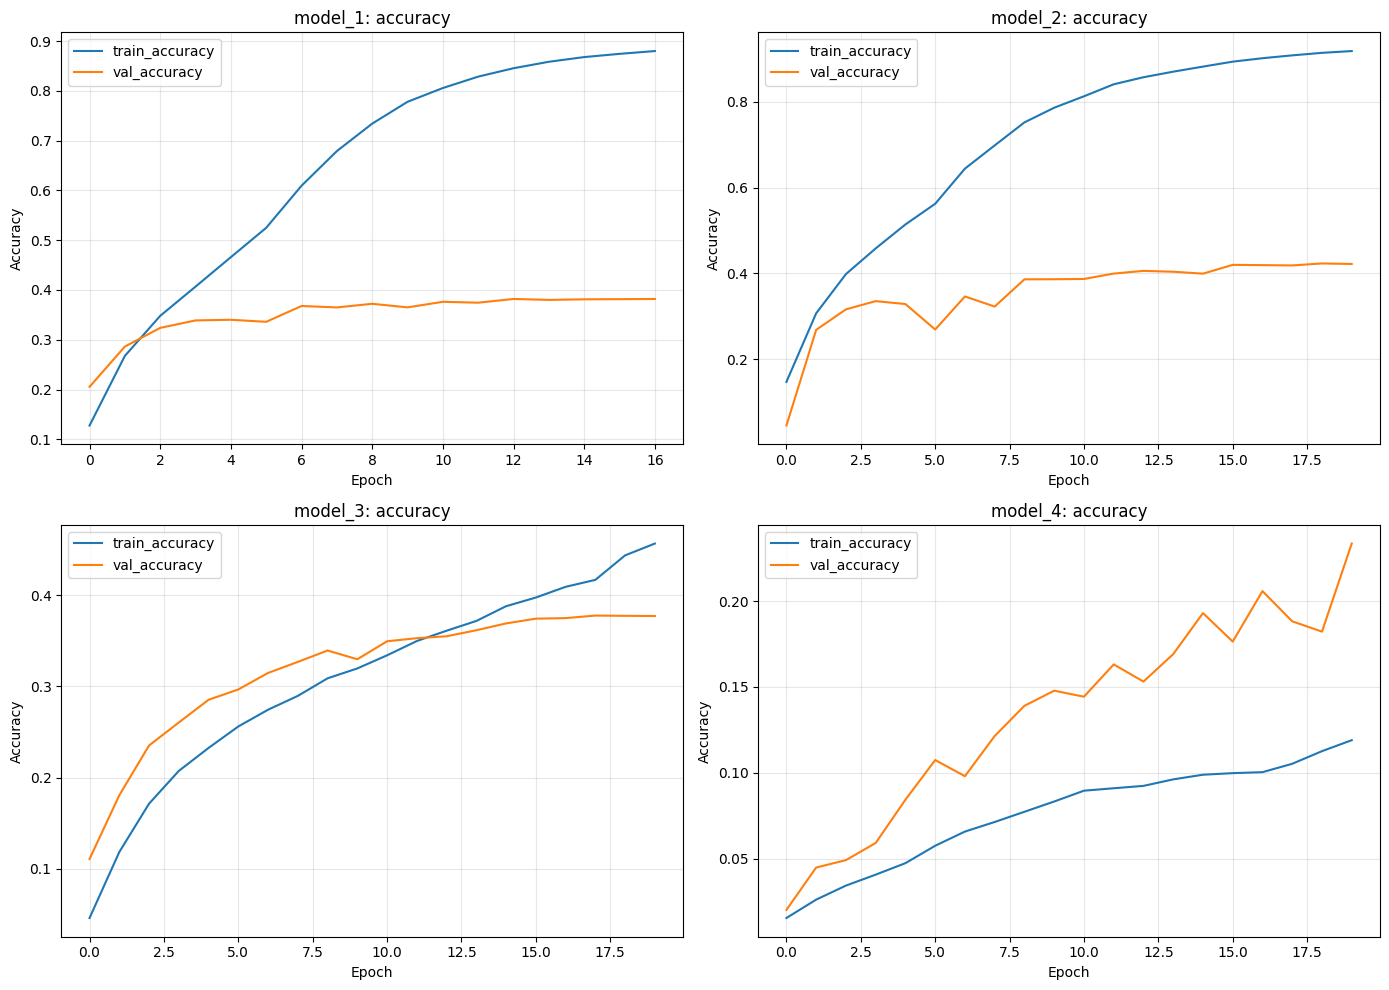

Сравнение моделей:


,model,best_val_accuracy,test_accuracy,best_val_loss
1,model_2,0.4231,0.4247,2.602347
0,model_1,0.3819,0.3801,2.716577
2,model_3,0.3776,0.3786,2.511818
3,model_4,0.2335,0.2363,3.156389


Лучшая модель по test_accuracy: model_2

Краткие выводы (автоматически):
model_2: best_val_acc=0.4231, test_acc=0.4247, best_val_loss=2.6023
model_1: best_val_acc=0.3819, test_acc=0.3801, best_val_loss=2.7166
model_3: best_val_acc=0.3776, test_acc=0.3786, best_val_loss=2.5118
model_4: best_val_acc=0.2335, test_acc=0.2363, best_val_loss=3.1564


In [12]:
# 1.8 Сравнение качества всех моделей + графики обучения
histories = {
    "model_1": history_1,
    "model_2": history_2,
    "model_3": history_3,
    "model_4": history_4,
}

test_scores = {
    "model_1": test_acc_1,
    "model_2": test_acc_2,
    "model_3": test_acc_3,
    "model_4": test_acc_4,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (name, hist) in enumerate(histories.items()):
    axes[i].plot(hist.history["accuracy"], label="train_accuracy")
    axes[i].plot(hist.history["val_accuracy"], label="val_accuracy")
    axes[i].set_title(f"{name}: accuracy")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame(
    {
        "model": list(histories.keys()),
        "best_val_accuracy": [max(histories[m].history["val_accuracy"]) for m in histories],
        "test_accuracy": [test_scores[m] for m in histories],
        "best_val_loss": [min(histories[m].history["val_loss"]) for m in histories],
    }
).sort_values("test_accuracy", ascending=False)

best_model_name = comparison_df.iloc[0]["model"]
print("Сравнение моделей:")
display(comparison_df)
print(f"Лучшая модель по test_accuracy: {best_model_name}")

print("\nКраткие выводы (автоматически):")
for _, row in comparison_df.iterrows():
    print(
        f"{row['model']}: best_val_acc={row['best_val_accuracy']:.4f}, "
        f"test_acc={row['test_accuracy']:.4f}, best_val_loss={row['best_val_loss']:.4f}"
    )

По графикам и метрикам видно, что добавление регуляризации (BatchNormalization и/или Dropout) повышает устойчивость обучения по сравнению с базовой моделью. Наиболее качественная модель определяется по таблице сравнения в предыдущей ячейке (best test accuracy).

Итог: для задачи классификации CIFAR-100 лучшей считаем модель, показавшую максимальную точность на тестовой выборке в сравнительной таблице. Как правило, комбинация BatchNormalization() + Dropout() даёт лучший баланс между скоростью сходимости и обобщающей способностью.

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

Сверточные слои: ['conv2d_9', 'conv2d_10', 'conv2d_11']
Выбранные классы: [0 1 2 3 4]


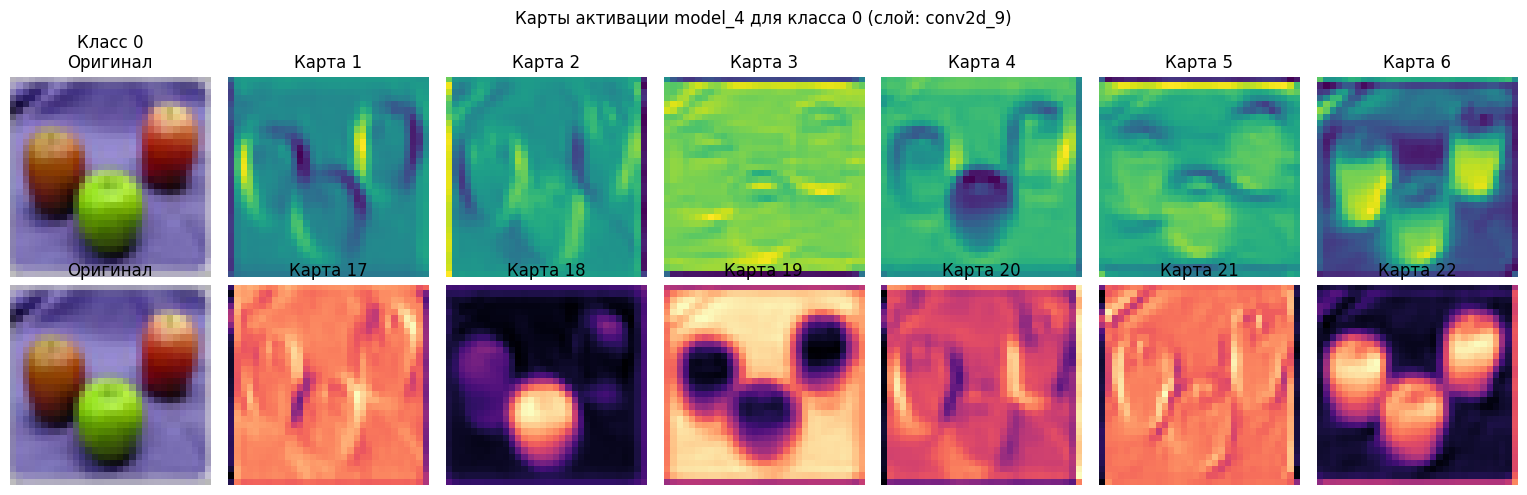

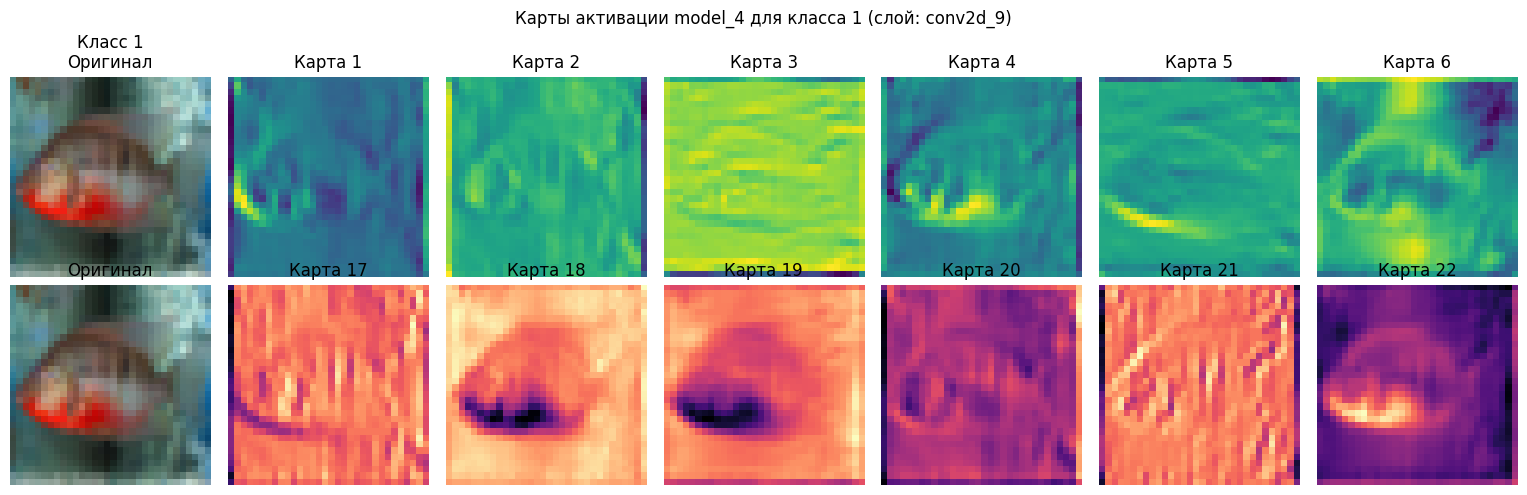

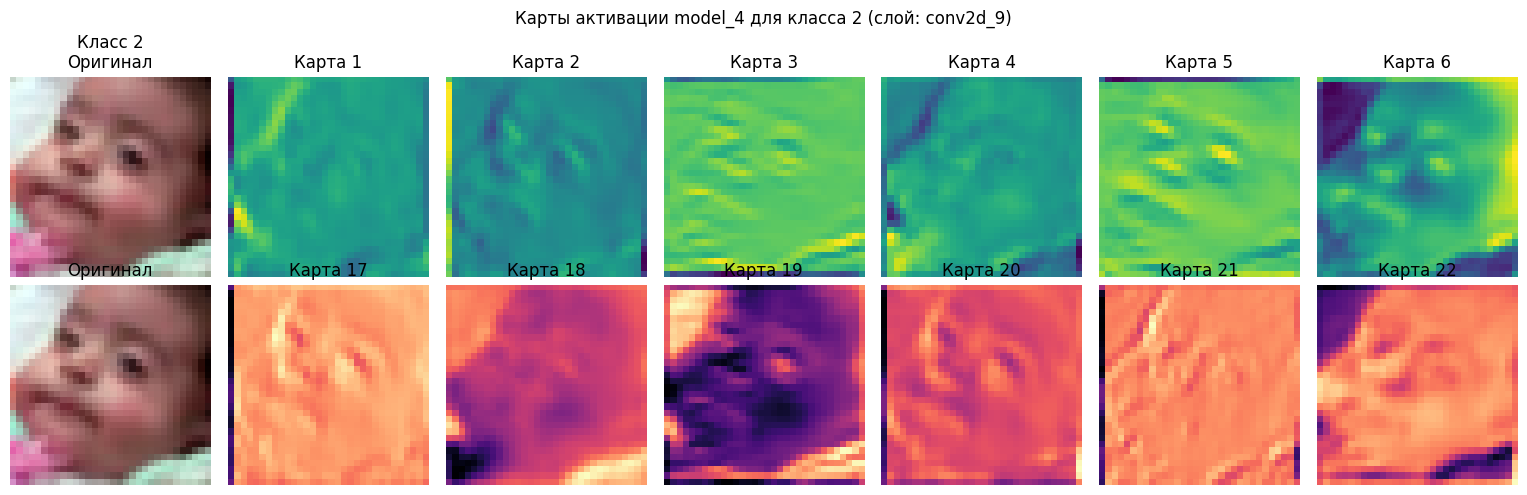

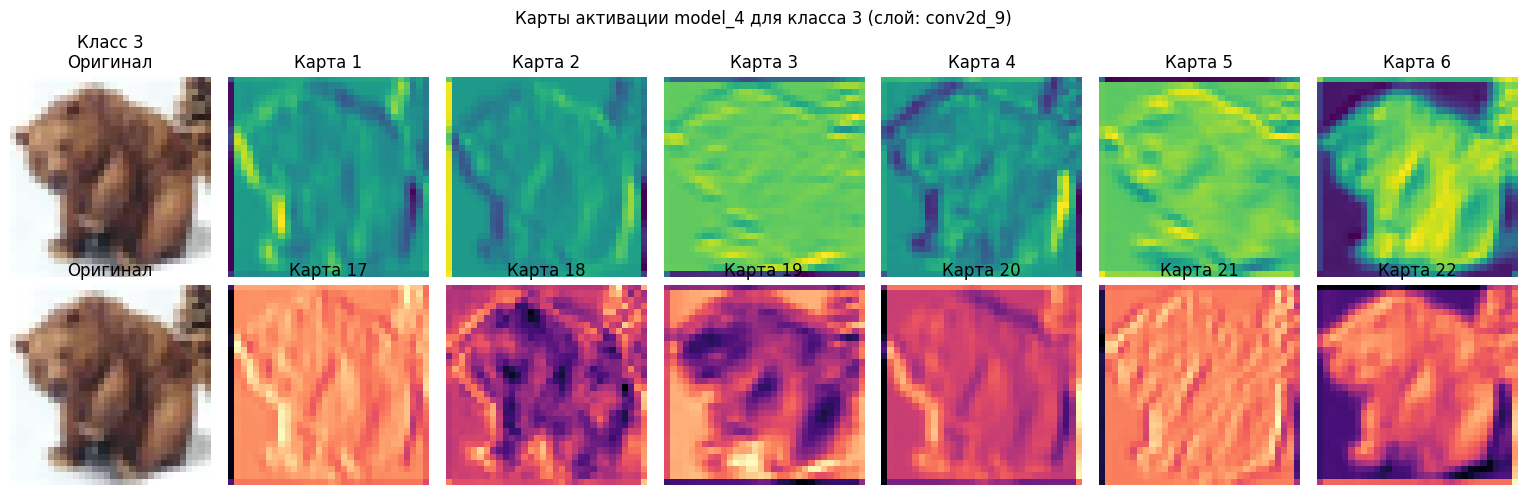

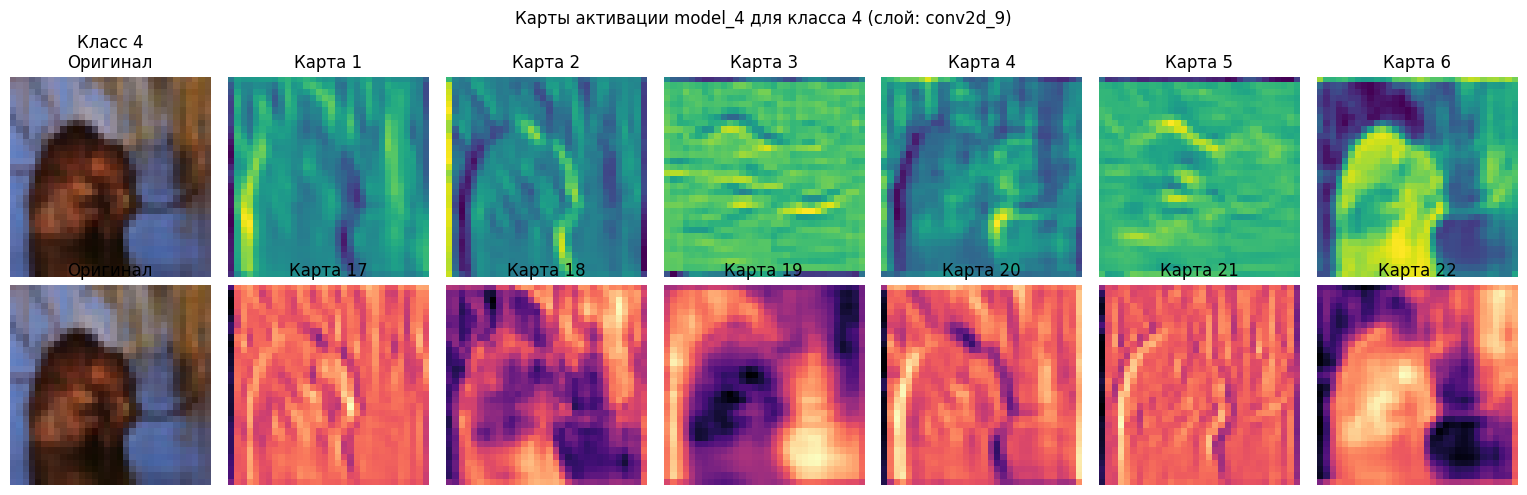

In [16]:
# 1.9 Визуализация карт активации model_4 отдельно по 5 классам
# Принудительная инициализация
if not model_4.built:
    model_4.build((None, *input_shape))
_ = model_4(x_test_norm[:1])

conv_layer_names = [layer.name for layer in model_4.layers if isinstance(layer, layers.Conv2D)]
print("Сверточные слои:", conv_layer_names)

# Извлекаем вход через первый слой, чтобы избежать ошибки атрибута модели
target_conv_layer = model_4.get_layer(conv_layer_names[0])
activation_model = tf.keras.Model(
    inputs=model_4.layers[0].input,
    outputs=target_conv_layer.output,
)

selected_classes = np.unique(y_test)[:5]
print("Выбранные классы:", selected_classes)

for class_id in selected_classes:
    idx = np.where(y_test == class_id)[0][0]
    sample = x_test_norm[idx:idx + 1]
    activation_maps = activation_model.predict(sample, verbose=0)[0]

    n_maps = 6
    fig, axes = plt.subplots(2, n_maps + 1, figsize=(2.2 * (n_maps + 1), 5))

    axes[0, 0].imshow(x_test[idx])
    axes[0, 0].set_title(f"Класс {class_id}\nОригинал")
    axes[0, 0].axis("off")

    axes[1, 0].imshow(x_test[idx])
    axes[1, 0].set_title("Оригинал")
    axes[1, 0].axis("off")

    for j in range(n_maps):
        axes[0, j + 1].imshow(activation_maps[:, :, j], cmap="viridis")
        axes[0, j + 1].set_title(f"Карта {j + 1}")
        axes[0, j + 1].axis("off")

        mid_idx = activation_maps.shape[-1] // 2 + j
        axes[1, j + 1].imshow(activation_maps[:, :, mid_idx], cmap="magma")
        axes[1, j + 1].set_title(f"Карта {mid_idx + 1}")
        axes[1, j + 1].axis("off")

    plt.suptitle(f"Карты активации model_4 для класса {class_id} (слой: {conv_layer_names[0]})")
    plt.tight_layout()
    plt.show()

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [17]:
import os
import json

# 1. Configure Kaggle API credentials
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_data = {"username":"YOUR_KAGGLE_USERNAME","key":"YOUR_KAGGLE_KEY"}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(kaggle_data, f)

os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)

# 2. Download the Playing Cards dataset
!kaggle datasets download -d gpiosenka/cards-image-datasetclassification

# 3. Unzip the dataset into 'playing_cards'
!mkdir -p playing_cards
!unzip -q cards-image-datasetclassification.zip -d playing_cards

# 4. Verify extraction
print("Contents of 'playing_cards':")
!ls playing_cards

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
100% 385M/385M [00:22<00:00, 17.9MB/s]

Contents of 'playing_cards':
'14card types-14-(200 X 200)-94.61.h5'	 cards.csv   train
'53cards-53-(200 X 200)-100.00.h5'	 test	     valid


In [19]:
import tensorflow as tf
from tensorflow.keras import layers
import os

# 1. Define paths
base_dir = "playing_cards"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# 2. Create datasets using image_dataset_from_directory
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Save class names before mapping
class_names = raw_train_ds.class_names

# 3. Normalization and Performance Optimization
normalization_layer = layers.Rescaling(1./255)

def prepare(ds):
    # Rescale inputs
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    # Cache and prefetch
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare(raw_train_ds)
val_ds = prepare(raw_val_ds)
test_ds = prepare(raw_test_ds)

print("\nData Pipeline Setup Complete.")
print(f"Number of classes: {len(class_names)}")
print(f"Class names example: {class_names[:5]}")

Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.
Found 265 files belonging to 53 classes.

Data Pipeline Setup Complete.
Number of classes: 53
Class names example: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs']


In [20]:
from tensorflow.keras import models, layers

# 1. Define the Sequential model
cards_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # 2. Add three convolutional blocks
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # 3. Flatten and Dense layer
    layers.Flatten(),
    layers.Dense(512, activation='relu'),

    # 4. Final Dropout layer
    layers.Dropout(0.5),

    # 5. Output layer for 53 classes
    layers.Dense(53, activation='softmax')
], name='cards_model')

# 6. Compile the model
cards_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Print model summary
cards_model.summary()

Model: "cards_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 53)             │        27,189 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,502,069 (196.46 MB)

 Trainable params: 51,501,621 (196.46 MB)

 Non-trainable params: 448 (1.75 KB)

In [23]:
# Задание 2
# 1) Загрузите свой датасет из предыдущей работы
# Ожидаемая структура:
# custom_dataset/
#   class_1/xxx.jpg
#   class_1/xxy.jpg
#   class_2/123.jpg
#   ...

custom_data_dir = Path("train")  # при необходимости поменяйте путь
IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE


def build_bn_dropout_model(num_classes_local, input_shape_local=(224, 224, 3)):
    model = models.Sequential(
        [
            layers.Input(shape=input_shape_local),
            layers.Conv2D(32, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),
            layers.Dropout(0.25),

            layers.Conv2D(64, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),
            layers.Dropout(0.30),

            layers.Conv2D(128, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling2D(),
            layers.Dropout(0.35),

            layers.Flatten(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(num_classes_local, activation="softmax"),
        ],
        name="custom_bn_dropout",
    )
    return compile_model(model)


if custom_data_dir.exists():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        custom_data_dir,
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",
    )

    test_ds = tf.keras.utils.image_dataset_from_directory(
        custom_data_dir,
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="int",
    )

    class_names_custom = train_ds.class_names
    num_classes_custom = len(class_names_custom)

    # Нормализация изображений
    norm_layer = layers.Rescaling(1.0 / 255)
    train_ds = train_ds.map(lambda x, y: (norm_layer(x), y)).cache().prefetch(AUTOTUNE)
    test_ds = test_ds.map(lambda x, y: (norm_layer(x), y)).cache().prefetch(AUTOTUNE)

    custom_model = build_bn_dropout_model(num_classes_custom, input_shape_local=(IMG_SIZE[0], IMG_SIZE[1], 3))
    custom_model.summary()

    history_custom = custom_model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=EPOCHS,
        callbacks=make_callbacks(),
        verbose=1,
    )

    custom_test_loss, custom_test_acc = custom_model.evaluate(test_ds, verbose=0)
    print(f"\nТочность custom_model на тесте: {custom_test_acc:.4f}")

    print("\nСравнение с моделями из задания 1:")
    if "comparison_df" in globals():
        display(comparison_df)
        best_cifar = comparison_df.iloc[0]
        print(
            f"Лучшая модель на CIFAR-100: {best_cifar['model']} "
            f"(test_acc={best_cifar['test_accuracy']:.4f})"
        )
    else:
        print("Сначала выполните ячейки задания 1.8 для получения comparison_df")

    print("\nКарта активаций для пользовательского датасета")
    conv_custom = [layer.name for layer in custom_model.layers if isinstance(layer, layers.Conv2D)]
    activation_custom = tf.keras.Model(
        inputs=custom_model.input,
        outputs=custom_model.get_layer(conv_custom[0]).output,
    )

    # Берем по одному примеру для первых 5 классов
    samples_by_class = {}
    for batch_images, batch_labels in test_ds:
        for img, lbl in zip(batch_images.numpy(), batch_labels.numpy()):
            lbl = int(lbl)
            if lbl not in samples_by_class:
                samples_by_class[lbl] = img
            if len(samples_by_class) >= min(5, num_classes_custom):
                break
        if len(samples_by_class) >= min(5, num_classes_custom):
            break

    for class_id, sample_img in samples_by_class.items():
        activ = activation_custom.predict(sample_img[None, ...], verbose=0)[0]

        fig, axes = plt.subplots(1, 7, figsize=(16, 3))
        axes[0].imshow(sample_img)
        axes[0].set_title(class_names_custom[class_id])
        axes[0].axis("off")

        for j in range(6):
            axes[j + 1].imshow(activ[:, :, j], cmap="viridis")
            axes[j + 1].set_title(f"Map {j + 1}")
            axes[j + 1].axis("off")

        plt.suptitle(f"Активации custom_model, класс: {class_names_custom[class_id]}")
        plt.tight_layout()
        plt.show()

else:
    print(
        "Папка custom_dataset не найдена. "
        "Создайте её и поместите внутрь подпапки классов с изображениями, затем перезапустите эту ячейку."
    )

Found 7624 files belonging to 53 classes.
Using 6100 files for training.
Found 7624 files belonging to 53 classes.
Using 1524 files for validation.


Model: "custom_bn_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 53)             │        13,621 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,798,133 (98.41 MB)

 Trainable params: 25,797,685 (98.41 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.0195 - loss: 7.0043 - val_accuracy: 0.0197 - val_loss: 3.9698 - learning_rate: 0.0010
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.0218 - loss: 3.9683 - val_accuracy: 0.0197 - val_loss: 3.9694 - learning_rate: 0.0010
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.0216 - loss: 3.9669 - val_accuracy: 0.0197 - val_loss: 3.9691 - learning_rate: 0.0010
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.0238 - loss: 3.9658 - val_accuracy: 0.0184 - val_loss: 3.9691 - learning_rate: 0.0010
Epoch 5/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0279 - loss: 3.9639
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.0251 - loss: 3.9650 - val_accuracy: 0.0184 - val_loss: 3.9692 - learning_rate: 0.0010
Epoch 5: early stopping
Restoring model weights from the end of the best epoc

,model,best_val_accuracy,test_accuracy,best_val_loss
1,model_2,0.4231,0.4247,2.602347
0,model_1,0.3819,0.3801,2.716577
2,model_3,0.3776,0.3786,2.511818
3,model_4,0.2335,0.2363,3.156389


Лучшая модель на CIFAR-100: model_2 (test_acc=0.4247)

Карта активаций для пользовательского датасета


AttributeError: The layer custom_bn_dropout has never been called and thus has no defined input.